## FCLGA GraphTransformer: Nonlinear Demo

This notebook demonstrated the complete FCLGA workflow for CFRP Strain Field Prediction on a Nonlinear Woven-Fabric Composite.

1. **Environment Setup** Verify the conda environment is activated and ready.
2. **Preprocessing pipeline:** 6-step pipeline generating 500 parametric samples.
3. **Training:** Hyperparameter optimized training.  
4. **Testing:** Evaluation on test set. 
5. **Results:** Display of strain field predictions.


## Step 1: Environment Setup

In [1]:
# Setup: Change to project root directory
import os
from pathlib import Path

# Get project root (parent of notebooks/)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
print(f"✓ Working directory: {PROJECT_ROOT}")

# Verify environment
import sys
print(f"✓ Python: {sys.version.split()[0]}")
print(f"✓ Conda environment: {Path(sys.prefix).name}")

# Quick import check
import torch
import torch_geometric
print(f"✓ PyTorch: {torch.__version__}")
print(f"✓ PyTorch Geometric: {torch_geometric.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ Working directory: /home/lpatrign/local-global-graph-transformer
✓ Python: 3.10.19
✓ Conda environment: fclga


/home/lpatrign/miniconda3/envs/fclga/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ PyTorch: 2.9.1+cu128
✓ PyTorch Geometric: 2.7.0
✓ CUDA available: True


## Step 2: Preprocessing Pipeline

In [3]:
# Step 2.1: Generate 500 parametric geometries (~5 min)
!abaqus cae nogui=src/preprocessing/nonlinear/fclga_generate_geometry.py

Abaqus License Manager checked out the following license:
"cae" from Flexnet server abaqus-research.cc.ic.ac.uk
<56 out of 57 licenses remain available>.


In [14]:
# Step 2.2: Run simulations (Dynamic/Explicit)
!python -m src.preprocessing.nonlinear.fclga_run_simulations

Found 500 geometry files to simulate
Input directory: /home/lpatrign/HybridAttentionGNN/data/raw/nonlinear/geometry
Output directory: /home/lpatrign/HybridAttentionGNN/data/raw/nonlinear/simulations

Running 500 simulations with 4 parallel workers

Starting Abaqus job: Plate_nonlinear_0
Starting Abaqus job: Plate_nonlinear_1
Starting Abaqus job: Plate_nonlinear_10
Starting Abaqus job: Plate_nonlinear_100
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_nonlinear_1
Abaqus 2024.HF3
USING MEMORY DOUG-LEA ALLOCATOR
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_nonlinear_100
Abaqus 2024.HF3
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_nonlinear_0
Abaqus 2024.HF3
Analysis initiated from SIMULIA established products
Abaqus JOB Plate_nonlinear_10
Abaqus 2024.HF3
USING MEMORY DOUG-LEA ALLOCATOR
USING MEMORY DOUG-LEA ALLOCATOR
USING MEMORY DOUG-LEA ALLOCATOR
Abaqus License Manager checked out the following licenses:
Abaqus/Exp

In [17]:
# Step 2.3: Extract strains
!abaqus cae nogui=src/preprocessing/nonlinear/fclga_extract_results.py

Abaqus License Manager checked out the following license:
"cae" from Flexnet server abaqus-research.cc.ic.ac.uk
<55 out of 57 licenses remain available>.


In [18]:
# Step 2.4: Extract features
!python -m src.preprocessing.nonlinear.fclga_extract_features

Reading geometry files from: /home/lpatrign/HybridAttentionGNN/data/raw/nonlinear/geometry
Output will be saved to: /home/lpatrign/HybridAttentionGNN/data/processed/nonlinear

Processing 500 geometry files...
  Processing: Plate_nonlinear_0.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_1.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_2.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_3.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_4.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_5.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_6.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_7.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_8.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processing: Plate_nonlinear_9.inp
    Nodes: 1223, Node ID range: [1, 1223]
  Processin

In [19]:
# Step 2.5: Build dataset
!python -m src.preprocessing.nonlinear.fclga_build_dataset

Reading strain files from: /home/lpatrign/HybridAttentionGNN/data/interim/nonlinear/strains
Reading node data from: /home/lpatrign/HybridAttentionGNN/data/processed/nonlinear
Output will be saved to: /home/lpatrign/HybridAttentionGNN/data/processed/nonlinear
Loaded 500 samples from node GNN data

Processing 500 strain files...
  Processing sample 1/500: E11_Plate_nonlinear_0.txt
  Processing sample 2/500: E11_Plate_nonlinear_1.txt
  Processing sample 3/500: E11_Plate_nonlinear_2.txt
  Processing sample 4/500: E11_Plate_nonlinear_3.txt
  Processing sample 5/500: E11_Plate_nonlinear_4.txt
  Processing sample 6/500: E11_Plate_nonlinear_5.txt
  Processing sample 7/500: E11_Plate_nonlinear_6.txt
  Processing sample 8/500: E11_Plate_nonlinear_7.txt
  Processing sample 9/500: E11_Plate_nonlinear_8.txt
  Processing sample 10/500: E11_Plate_nonlinear_9.txt
  Processing sample 11/500: E11_Plate_nonlinear_10.txt
  Processing sample 12/500: E11_Plate_nonlinear_11.txt
  Processing sample 13/500: E1

In [21]:
# Step 2.6: Prepare training data
!python -m src.preprocessing.nonlinear.fclga_prepare_training_data

FCLGA Training Data Preparation
Loading preprocessed data...
✓ Loaded 500 graph samples
✓ Loaded 500 strain samples
✓ Loaded geometry data: torch.Size([500, 6])

Processing 500 samples...
Graph is already bidirectional.
  Processing sample 1/500...

First sample statistics:
  Geometry: L=125.97, W=149.61, radius=19.00, displacement=1.0000
  Hole edge nodes: 12.0
  Fixed boundary nodes: 66
  Displaced boundary nodes: 28
  Distance tolerance: 0.9501
  Processing sample 100/500...
  Processing sample 200/500...
  Processing sample 300/500...
  Processing sample 400/500...
  Processing sample 500/500...
✓ Processed all 500 samples

✓ Saved processed data to: /home/lpatrign/HybridAttentionGNN/data/processed/nonlinear/datasets/processed_data.pt

Data Summary
Number of samples: 500
Node features: [x, y, is_hole_edge, is_fixed, is_displaced, displacement_amount]
Node feature shape: torch.Size([1261, 6])
Edge index shape: torch.Size([2, 7050])
Edge attribute shape: torch.Size([7050, 3])
Target 

## Step 3: Training

In [2]:
# Train with hyperparameter optimization

# python -m src.training.fclga_train_model \
#     --material_type nonlinear \
#     --optimize \
#     --optuna_trials 25 \
#     --epochs 50 \
#     --final_epochs 600 \
#     2>&1 | tee notebooks/train_nonlinear.log

# Display the log from the previous run:
from pathlib import Path

log_file = Path("notebooks/train_nonlinear.log")
if log_file.exists():
    log_content = log_file.read_text()
    print(log_content[-20000:])

 0.16948
Epoch 419: Train Loss = 0.16135, Val Loss = 0.16702
Epoch 420: Train Loss = 0.16815, Val Loss = 0.16805
Epoch 421: Train Loss = 0.15669, Val Loss = 0.17132
Epoch 422: Train Loss = 0.16163, Val Loss = 0.17080
Epoch 423: Train Loss = 0.17786, Val Loss = 0.17036
Epoch 424: Train Loss = 0.15782, Val Loss = 0.17002
Epoch 425: Train Loss = 0.17041, Val Loss = 0.17126
Epoch 426: Train Loss = 0.16757, Val Loss = 0.17348
Epoch 427: Train Loss = 0.17942, Val Loss = 0.16788
Epoch 428: Train Loss = 0.17572, Val Loss = 0.16924
Epoch 429: Train Loss = 0.18531, Val Loss = 0.16992
Epoch 430: Train Loss = 0.18004, Val Loss = 0.17598
Epoch 431: Train Loss = 0.16153, Val Loss = 0.16960
Epoch 432: Train Loss = 0.15260, Val Loss = 0.17674
Epoch 433: Train Loss = 0.13864, Val Loss = 0.17266
Epoch 434: Train Loss = 0.16945, Val Loss = 0.16867
Epoch 435: Train Loss = 0.16404, Val Loss = 0.17179
Epoch 436: Train Loss = 0.17260, Val Loss = 0.17269
Epoch 437: Train Loss = 0.16369, Val Loss = 0.16740
Epo

## Step 4: Testing

Evaluate the trained model on the test set. Use `--training_run` to automatically load the best model and hyperparameters from a training run directory.

**Estimated time:** ~5 minutes

In [3]:
# Test the model - update the training_run path with your timestamp
!python -m src.evaluation.fclga_test \
    --training_run results/nonlinear/training_nonlinear_20260109_182307 \
    --material_type nonlinear

AUTO-LOADING FROM TRAINING RUN
Training run directory: results/nonlinear/training_nonlinear_20260109_182307

Loading hyperparameters from: results/nonlinear/training_nonlinear_20260109_182307/hyperparameter_optimization_results/best_hyperparameters.json
Found final trained model: model_nl5_bs4_hd128_ep600_wd3.0045972921492656e-07_lr0.00036268409381325187_shuff_True_tr350_te75_FINAL.pt

Loaded hyperparameters:
  num_layers: 5
  attention_freq: 3
  batch_size: 4
  hidden_dim: 128
  dropout_rate: 0.21496792657170033
  opt: rmsprop
  opt_decay_step: 40
  opt_decay_rate: 0.7447788576539163
  weight_decay: 3.0045972921492656e-07
  lr: 0.00036268409381325187

✓ Hyperparameters and model path loaded successfully!

FCLGA GRAPHTRANSFORMER - MODEL TESTING

Model checkpoint: results/nonlinear/training_nonlinear_20260109_182307/best_models/model_nl5_bs4_hd128_ep600_wd3.0045972921492656e-07_lr0.00036268409381325187_shuff_True_tr350_te75_FINAL.pt
Device: cuda
Loading dataset from: /home/lpatrign/loca

## Step 5: View Results

Test results are automatically saved as PDFs showing strain field predictions vs ground truth.

**Location:** `results/nonlinear/training_nonlinear_TIMESTAMP/test_sample_X_results.pdf`

Let's display one example result:

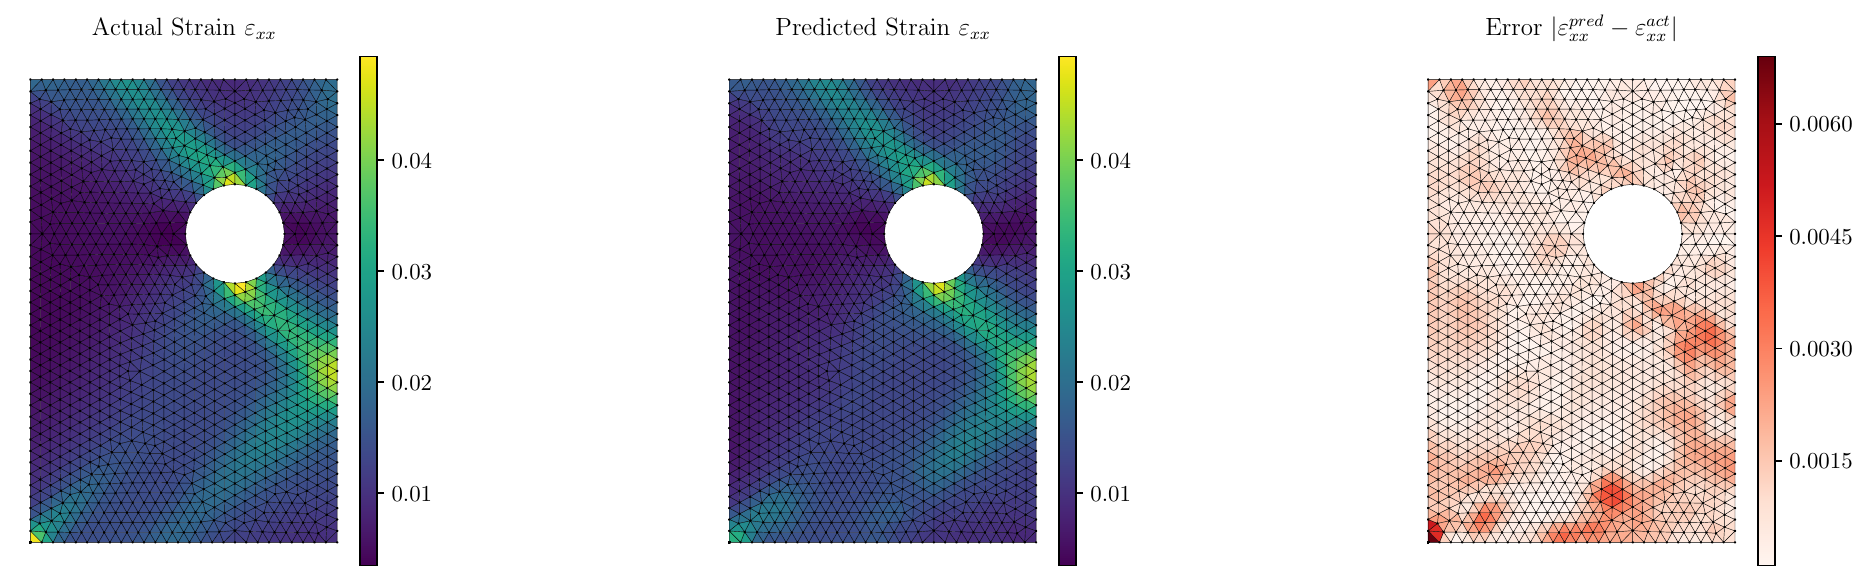

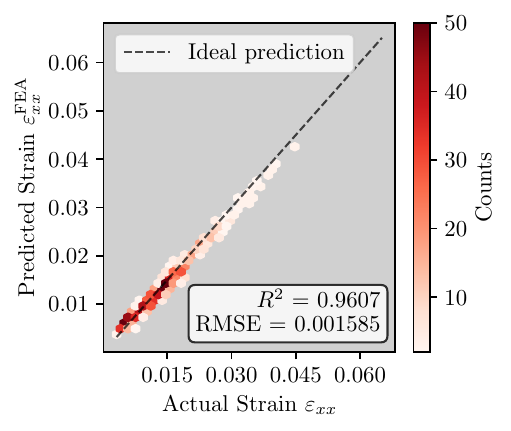

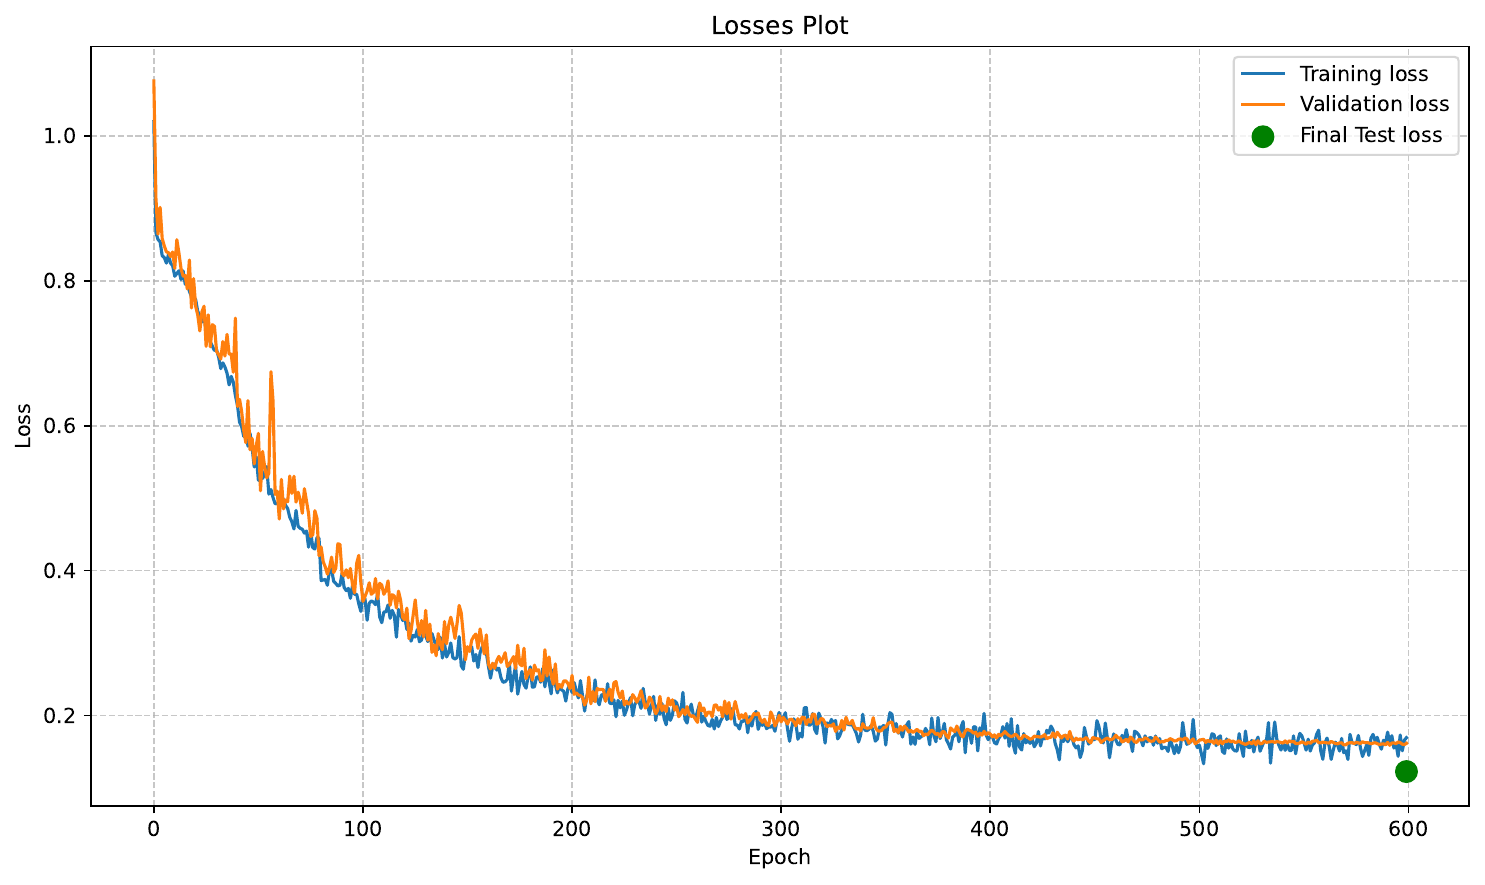

In [6]:
# Display test results
from pathlib import Path
from IPython.display import display, Image, HTML
import subprocess

training_run = "results/nonlinear/training_nonlinear_20260109_182307"

# Find training losses PDF
losses_dir = Path(training_run) / "training_results"
losses_pdf = list(losses_dir.glob("Losses_*.pdf"))[0] if losses_dir.exists() and list(losses_dir.glob("Losses_*.pdf")) else None

pdfs = [
    ("Strain Field Prediction", 
     Path(training_run) / "test_results/test_sample_22_results_data/test_sample_22_results.pdf", 
     800),
    ("Regression Analysis", 
     Path(training_run) / "test_results/test_sample_22_results_data/test_sample_22_results_regression.pdf", 
     450),
    ("Training Loss Curves", losses_pdf, 800)
]

def show_pdf(pdf_path, title, width):
    if pdf_path is None or not pdf_path.exists():
        return False
    
    png_path = pdf_path.with_suffix('.png')
    result = subprocess.run(
        ['pdftoppm', '-png', '-singlefile', '-r', '150', str(pdf_path), str(png_path.with_suffix(''))],
        capture_output=True, text=True
    )
    
    if result.returncode == 0 and png_path.exists():
        display(HTML(f"<h3 style='margin: 30px 0 10px 0; color: #2196F3;'>{title}</h3>"))
        display(Image(filename=str(png_path), width=width))
        return True
    return False

display(HTML("<h2 style='color: #4CAF50;'>Test Results & Training Metrics</h2>"))

for title, path, width in pdfs:
    show_pdf(path, title, width)